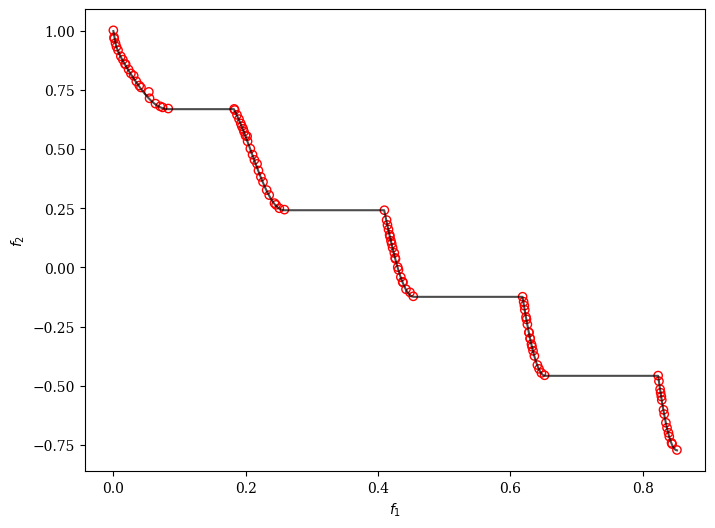

In [14]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("zdt3")

algorithm = NSGA2(pop_size=100)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()


  Solving ZDT1 | pop=100 | gen=200 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/200 | Front-0 size: 97
  Gen  100/200 | Front-0 size: 89
  Gen  150/200 | Front-0 size: 100
  Gen  200/200 | Front-0 size: 100

  ┌─ Timing Summary: ZDT1 ──────────────────────────────
  │  Total wall-clock time  :    3.537 s
  │  Generations            : 200
  │  Avg time / generation  :    17.69 ms
  │
  │  Phase breakdown (cumulative across all generations):
  │    init        :   0.008 s  (  0.2%)  
  │    selection   :   0.463 s  ( 13.1%)  ██████
  │    variation   :   1.521 s  ( 43.0%)  █████████████████████
  │    evaluation  :   0.213 s  (  6.0%)  ███
  │    survival    :   1.331 s  ( 37.6%)  ██████████████████
  │    overhead    :   0.001 s  (  0.0%)
  └──────────────────────────────────────────────────

  ✓ ZDT1 done | Initial pop: 100 | Final front-0: 100 | Time: 3.537s

  Solving ZDT2 | pop=100 | gen=200 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/200 | Front-0 size: 4
  Gen  100/2

C:\Users\hp\AppData\Local\Temp\ipykernel_12032\333067725.py:448: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_12032\333067725.py:449: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')



Plot saved as ZDT_initial_vs_final_improved.png


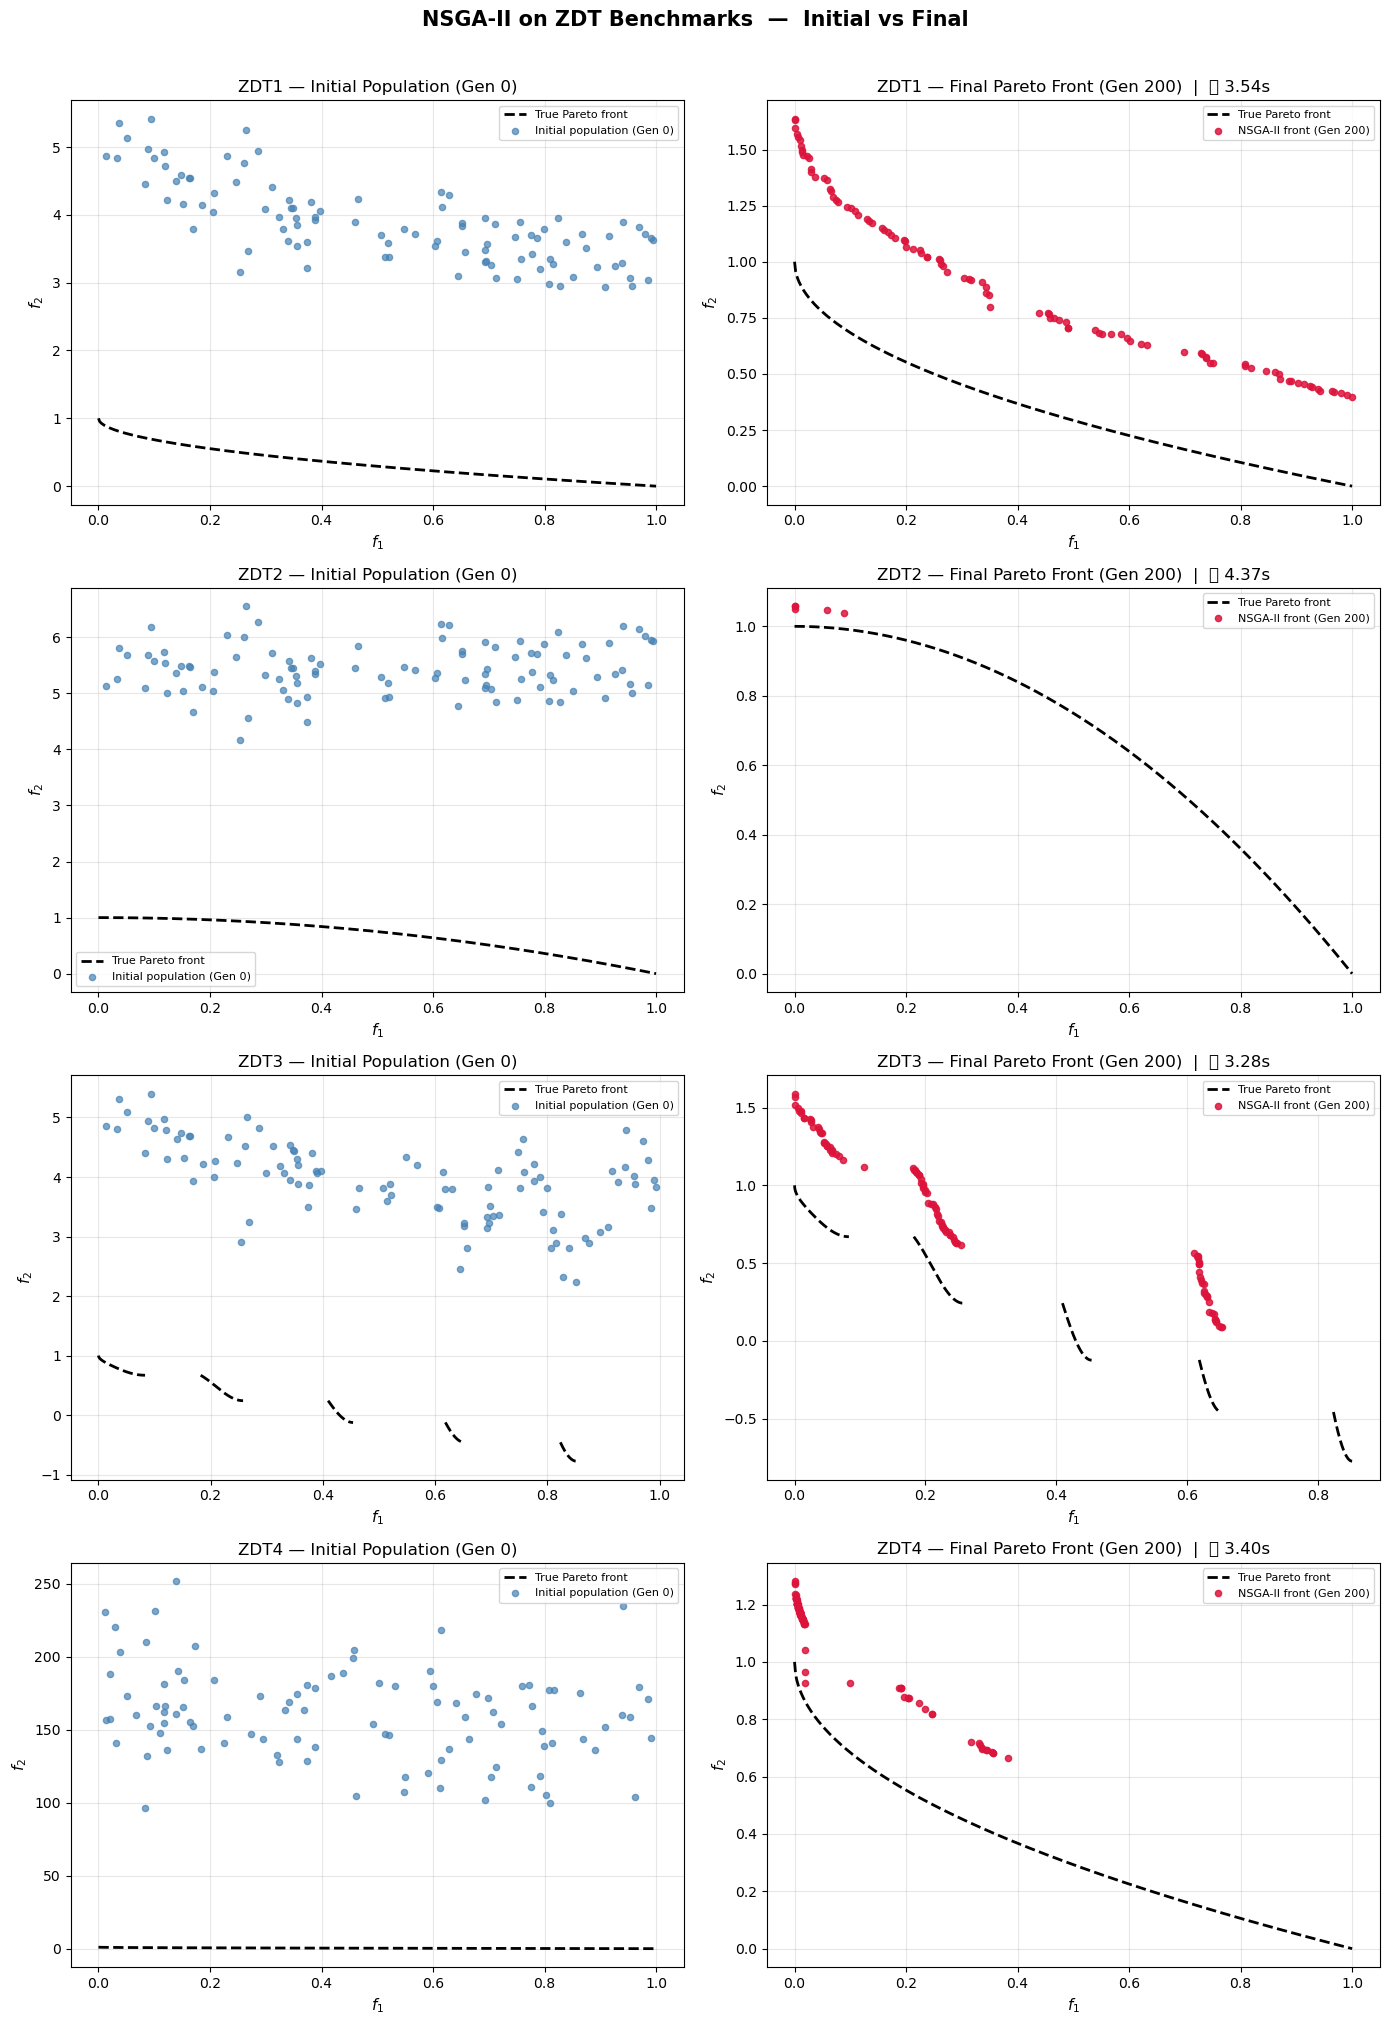

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# ZDT Problem Definitions
# -----------------------------------------------------------------------

def zdt1(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


def zdt2(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - (f1 / g) ** 2)])


def zdt3(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    return np.array([f1, g * h])


def zdt4(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 10 * (n - 1) + np.sum(x[1:] ** 2 - 10 * np.cos(4 * np.pi * x[1:]))
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


# -----------------------------------------------------------------------
# NSGA-II Core Functions
# -----------------------------------------------------------------------

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def non_dominated_sorting(pop_objs):
    """
    IMPROVEMENT: Uses NumPy broadcasting to compute the full dominance
    matrix in one vectorised call instead of a pure-Python double loop,
    cutting runtime of this O(N²) step significantly.
    """
    N = len(pop_objs)

    # --- Vectorised dominance matrix -----------------------------------
    # a_mat[i,j] = True  iff  pop_objs[i] dominates pop_objs[j]
    objs_i = pop_objs[:, np.newaxis, :]   # (N, 1, M)
    objs_j = pop_objs[np.newaxis, :, :]   # (1, N, M)

    all_leq  = np.all(objs_i <= objs_j, axis=2)   # (N, N) — i ≤ j on every obj
    any_less = np.any(objs_i <  objs_j, axis=2)   # (N, N) — i <  j on at least one
    dom_mat  = all_leq & any_less                  # dom_mat[i,j] = i dominates j
    np.fill_diagonal(dom_mat, False)

    n_dom  = dom_mat.sum(axis=0).astype(int)       # how many solutions dominate i
    dom_set = [list(np.where(dom_mat[i])[0]) for i in range(N)]
    # -------------------------------------------------------------------

    fronts = []
    current_front = list(np.where(n_dom == 0)[0])
    fronts.append(current_front)

    while fronts[-1]:
        next_front = []
        for i in fronts[-1]:
            for j in dom_set[i]:
                n_dom[j] -= 1
                if n_dom[j] == 0:
                    next_front.append(j)
        fronts.append(next_front)

    if fronts and fronts[-1] == []:
        fronts.pop()

    return fronts


def crowding_distance(objs, indices):
    n = len(indices)
    if n <= 2:
        return [np.inf] * n

    dist = np.zeros(n)
    idx_to_pos = {idx: pos for pos, idx in enumerate(indices)}

    for m in range(objs.shape[1]):
        sorted_idx = sorted(indices, key=lambda i: objs[i, m])
        dist[idx_to_pos[sorted_idx[0]]]  = np.inf
        dist[idx_to_pos[sorted_idx[-1]]] = np.inf

        f_min = objs[sorted_idx[0],  m]
        f_max = objs[sorted_idx[-1], m]

        if f_max - f_min > 0:
            for k in range(1, n - 1):
                dist[idx_to_pos[sorted_idx[k]]] += (
                    objs[sorted_idx[k + 1], m] - objs[sorted_idx[k - 1], m]
                ) / (f_max - f_min)

    return list(dist)


def tournament_selection(ranks, crowding):
    """
    IMPROVEMENT: Sample i and j WITHOUT replacement so a solution is
    never compared against itself, removing the self-tournament bias.
    """
    i, j = np.random.choice(len(ranks), size=2, replace=False)

    if ranks[i] < ranks[j]:
        return i
    elif ranks[j] < ranks[i]:
        return j
    elif crowding[i] > crowding[j]:
        return i
    else:
        return j


def sbx_crossover(p1, p2, eta_c, xl, xu):
    u = np.random.random(len(p1))
    beta = np.where(
        u <= 0.5,
        (2.0 * u) ** (1.0 / (eta_c + 1)),
        (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1))
    )
    y1 = 0.5 * ((1 + beta) * p1 + (1 - beta) * p2)
    y2 = 0.5 * ((1 - beta) * p1 + (1 + beta) * p2)
    return np.clip(y1, xl, xu), np.clip(y2, xl, xu)


def polynomial_mutation(ind, eta_m, pm, xl, xu):
    """
    IMPROVEMENT: Fully vectorised — replaces the pure-Python per-variable
    for-loop with NumPy operations, giving a significant speedup for large
    n_var (e.g. 30 variables).
    """
    y      = ind.copy()
    mask   = np.random.random(len(ind)) < pm          # which genes mutate

    if not np.any(mask):
        return y

    r      = np.random.random(len(ind))
    delta  = np.where(
        r < 0.5,
        (2.0 * r) ** (1.0 / (eta_m + 1)) - 1.0,
        1.0 - (2.0 * (1.0 - r)) ** (1.0 / (eta_m + 1))
    )
    y[mask] += delta[mask] * (xu[mask] - xl[mask])
    return np.clip(y, xl, xu)


# -----------------------------------------------------------------------
# IMPROVEMENT: compute_ranks_and_crowding moved to module level
# (was re-defined inside nsga2() on every call — wasteful)
# -----------------------------------------------------------------------

def compute_ranks_and_crowding(objs, size):
    fronts   = non_dominated_sorting(objs)
    ranks    = np.zeros(size, dtype=int)
    crowding = np.zeros(size)
    for rk, front in enumerate(fronts):
        for i in front:
            ranks[i] = rk
        cd = crowding_distance(objs, front)
        for pos, i in enumerate(front):
            crowding[i] = cd[pos]
    return ranks, crowding, fronts


# -----------------------------------------------------------------------
# Main NSGA-II Loop
# -----------------------------------------------------------------------

def nsga2(problem_func, n_var, bounds,
          pop_size=100, n_gen=200,
          pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42):
    """
    Returns
    -------
    population   : ndarray  Final population (decision variables)
    objectives   : ndarray  Final objective values
    init_objs    : ndarray  Objective values of the initial random population
    phase_times  : dict     Cumulative wall-clock seconds per internal phase:
                              'init'       — population init + first eval
                              'selection'  — tournament selection
                              'variation'  — SBX crossover + poly mutation
                              'evaluation' — offspring objective evaluation
                              'survival'   — merge + NDS + survivor selection
    """
    np.random.seed(seed)

    xl = np.array([b[0] for b in bounds])
    xu = np.array([b[1] for b in bounds])

    if pm is None:
        pm = 1.0 / n_var

    phase_times = dict(init=0.0, selection=0.0,
                       variation=0.0, evaluation=0.0, survival=0.0)

    # ------------------------------------------------------------------
    # Phase: Initialization
    # ------------------------------------------------------------------
    t0 = time.perf_counter()
    population = np.array([np.random.uniform(xl, xu) for _ in range(pop_size)])
    objectives = np.array([problem_func(ind) for ind in population])
    init_objectives = objectives.copy()
    ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
    phase_times['init'] += time.perf_counter() - t0

    # ------------------------------------------------------------------
    # Generational loop
    # ------------------------------------------------------------------
    for gen in range(n_gen):

        # ---- Phase: Selection ----------------------------------------
        t0 = time.perf_counter()
        mating_pool = np.array([
            population[tournament_selection(ranks, crowding)]
            for _ in range(pop_size)
        ])
        phase_times['selection'] += time.perf_counter() - t0

        # ---- Phase: Variation ----------------------------------------
        # IMPROVEMENT: offspring_raw dead variable removed
        t0 = time.perf_counter()
        offspring_pop = []
        for k in range(0, pop_size, 2):
            p1 = mating_pool[k]
            p2 = mating_pool[k + 1] if k + 1 < pop_size else mating_pool[0]

            if np.random.random() < pc:
                c1, c2 = sbx_crossover(p1, p2, eta_c, xl, xu)
            else:
                c1, c2 = p1.copy(), p2.copy()

            offspring_pop.append(polynomial_mutation(c1, eta_m, pm, xl, xu))
            offspring_pop.append(polynomial_mutation(c2, eta_m, pm, xl, xu))

        offspring_pop = np.array(offspring_pop[:pop_size])
        phase_times['variation'] += time.perf_counter() - t0

        # ---- Phase: Evaluation ---------------------------------------
        t0 = time.perf_counter()
        offspring_objs = np.array([problem_func(ind) for ind in offspring_pop])
        phase_times['evaluation'] += time.perf_counter() - t0

        # ---- Phase: Survival selection -------------------------------
        t0 = time.perf_counter()
        combined_pop  = np.vstack((population, offspring_pop))
        combined_objs = np.vstack((objectives, offspring_objs))

        ranks_comb, crowding_comb, _ = compute_ranks_and_crowding(
            combined_objs, len(combined_pop)
        )

        # IMPROVEMENT: np.lexsort replaces Python sorted() + lambda
        # np.lexsort sorts by last key first, so: primary = rank (asc),
        # secondary = crowding (desc, hence negative)
        sorted_indices = np.lexsort((-crowding_comb, ranks_comb))
        survivors  = sorted_indices[:pop_size]
        population = combined_pop[survivors]
        objectives = combined_objs[survivors]

        ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
        phase_times['survival'] += time.perf_counter() - t0

        if (gen + 1) % 50 == 0:
            n_front0 = len(fronts[0]) if fronts else 0
            print(f"  Gen {gen + 1:4d}/{n_gen} | Front-0 size: {n_front0}")

    return population, objectives, init_objectives, phase_times


# -----------------------------------------------------------------------
# True Pareto Fronts
# -----------------------------------------------------------------------

def true_pareto_zdt1():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - np.sqrt(f1)


def true_pareto_zdt2():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - f1 ** 2


def true_pareto_zdt3():
    intervals = [
        (0.0000, 0.0830), (0.1822, 0.2577), (0.4093, 0.4538),
        (0.6183, 0.6525), (0.8233, 0.8518)
    ]
    f1_list, f2_list = [], []
    for a, b in intervals:
        f1 = np.linspace(a, b, 200)
        f2 = 1 - np.sqrt(f1) - f1 * np.sin(10 * np.pi * f1)
        f1_list.extend(list(f1) + [np.nan])
        f2_list.extend(list(f2) + [np.nan])
    return np.array(f1_list[:-1]), np.array(f2_list[:-1])


def true_pareto_zdt4():
    return true_pareto_zdt1()


# -----------------------------------------------------------------------
# Timing summary
# -----------------------------------------------------------------------

def print_timing_summary(name, total_time, phase_times, n_gen):
    phases_total = sum(phase_times.values())
    overhead     = total_time - phases_total       # time outside timed blocks
    print(f"\n  ┌─ Timing Summary: {name} {'─'*30}")
    print(f"  │  Total wall-clock time  : {total_time:8.3f} s")
    print(f"  │  Generations            : {n_gen}")
    print(f"  │  Avg time / generation  : {total_time / n_gen * 1000:8.2f} ms")
    print(f"  │")
    print(f"  │  Phase breakdown (cumulative across all generations):")
    for phase, t in phase_times.items():
        pct = 100.0 * t / total_time
        bar = '█' * int(pct / 2)
        print(f"  │    {phase:<12s}: {t:7.3f} s  ({pct:5.1f}%)  {bar}")
    # IMPROVEMENT: overhead line added so percentages always sum to 100 %
    overhead_pct = 100.0 * overhead / total_time
    print(f"  │    {'overhead':<12s}: {overhead:7.3f} s  ({overhead_pct:5.1f}%)")
    print(f"  └{'─'*50}")


# -----------------------------------------------------------------------
# Plotting helper
# -----------------------------------------------------------------------

def plot_problem(ax_init, ax_final, name,
                 init_objs, final_objs,
                 f1_true, f2_true, n_gen, total_time):

    ax_init.plot(f1_true, f2_true, 'k--', linewidth=2,
                 label='True Pareto front', zorder=2)
    ax_init.scatter(init_objs[:, 0], init_objs[:, 1],
                    c='steelblue', s=20, alpha=0.7,
                    label='Initial population (Gen 0)', zorder=3)
    ax_init.set_xlabel('$f_1$', fontsize=11)
    ax_init.set_ylabel('$f_2$', fontsize=11)
    ax_init.set_title(f'{name} — Initial Population (Gen 0)', fontsize=12)
    ax_init.legend(fontsize=8)
    ax_init.grid(True, alpha=0.3)

    ax_final.plot(f1_true, f2_true, 'k--', linewidth=2,
                  label='True Pareto front', zorder=2)
    ax_final.scatter(final_objs[:, 0], final_objs[:, 1],
                     c='crimson', s=20, alpha=0.85,
                     label=f'NSGA-II front (Gen {n_gen})', zorder=3)
    ax_final.set_xlabel('$f_1$', fontsize=11)
    ax_final.set_ylabel('$f_2$', fontsize=11)
    ax_final.set_title(
        f'{name} — Final Pareto Front (Gen {n_gen})  |  ⏱ {total_time:.2f}s',
        fontsize=12
    )
    ax_final.legend(fontsize=8)
    ax_final.grid(True, alpha=0.3)


# -----------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------

def main():
    problems = [
        ("ZDT1", zdt1, 30, [(0, 1)] * 30,             true_pareto_zdt1, 200),
        ("ZDT2", zdt2, 30, [(0, 1)] * 30,             true_pareto_zdt2, 200),
        ("ZDT3", zdt3, 30, [(0, 1)] * 30,             true_pareto_zdt3, 200),
        ("ZDT4", zdt4, 10, [(0, 1)] + [(-5, 5)] * 9,  true_pareto_zdt4, 200),
    ]

    n_problems = len(problems)
    fig, axes  = plt.subplots(n_problems, 2, figsize=(14, 5 * n_problems))

    timing_records = []
    overall_start  = time.perf_counter()

    for row, (name, func, n_var, bounds, true_func, n_gen) in enumerate(problems):
        print(f"\n{'='*60}")
        print(f"  Solving {name} | pop=100 | gen={n_gen} | "
              f"pc=0.9 | pm=1/n | eta_c=15 | eta_m=20")
        print(f"{'='*60}")

        problem_start = time.perf_counter()
        pop, objs, init_objs, phase_times = nsga2(
            func, n_var, bounds,
            pop_size=100, n_gen=n_gen,
            pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42
        )
        total_time = time.perf_counter() - problem_start

        fronts = non_dominated_sorting(objs)
        front0 = objs[fronts[0]]
        front0 = front0[np.argsort(front0[:, 0])]

        f1_true, f2_true = true_func()
        plot_problem(axes[row, 0], axes[row, 1], name,
                     init_objs, front0,
                     f1_true, f2_true, n_gen, total_time)

        print_timing_summary(name, total_time, phase_times, n_gen)
        timing_records.append(
            dict(name=name, n_gen=n_gen, total=total_time, phases=phase_times)
        )
        print(f"\n  ✓ {name} done | Initial pop: {len(init_objs)} | "
              f"Final front-0: {len(front0)} | Time: {total_time:.3f}s")

    overall_time = time.perf_counter() - overall_start

    # Consolidated table
    print(f"\n{'='*60}")
    print(f"  CONSOLIDATED TIMING TABLE")
    print(f"{'='*60}")
    header = (f"  {'Problem':<8} {'Gens':>5} {'Total(s)':>10} {'Init(s)':>9} "
              f"{'Select(s)':>10} {'Vary(s)':>9} {'Eval(s)':>9} "
              f"{'Survive(s)':>11} {'ms/gen':>8}")
    print(header)
    print(f"  {'-'*98}")
    for r in timing_records:
        p  = r['phases']
        ms = r['total'] / r['n_gen'] * 1000
        print(
            f"  {r['name']:<8} {r['n_gen']:>5} {r['total']:>10.3f} "
            f"{p['init']:>9.3f} {p['selection']:>10.3f} {p['variation']:>9.3f} "
            f"{p['evaluation']:>9.3f} {p['survival']:>11.3f} {ms:>8.2f}"
        )
    print(f"  {'-'*98}")
    print(f"  {'TOTAL':<8} {'':>5} {overall_time:>10.3f}")
    print(f"{'='*60}")

    plt.suptitle('NSGA-II on ZDT Benchmarks  —  Initial vs Final',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as ZDT_initial_vs_final_improved.png")
    plt.show()


if __name__ == "__main__":
    main()


  Solving ZDT1 | pop=100 | gen=300 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/300 | Front-0 size: 97
  Gen  100/300 | Front-0 size: 89
  Gen  150/300 | Front-0 size: 100
  Gen  200/300 | Front-0 size: 100
  Gen  250/300 | Front-0 size: 100
  Gen  300/300 | Front-0 size: 100

  ┌─ Timing Summary: ZDT1 ──────────────────────────────
  │  Total wall-clock time  :    7.029 s
  │  Generations            : 300
  │  Avg time / generation  :    23.43 ms
  │
  │  Phase breakdown (cumulative across all generations):
  │    init        :   0.009 s  (  0.1%)  
  │    selection   :   0.937 s  ( 13.3%)  ██████
  │    variation   :   3.027 s  ( 43.1%)  █████████████████████
  │    evaluation  :   0.435 s  (  6.2%)  ███
  │    survival    :   2.618 s  ( 37.2%)  ██████████████████
  │    overhead    :   0.003 s  (  0.0%)
  └──────────────────────────────────────────────────

  ✓ ZDT1 done | Initial pop: 100 | Final front-0: 100 | Time: 7.029s

  Solving ZDT2 | pop=100 | gen=300 | pc=0.9 | pm=1

C:\Users\hp\AppData\Local\Temp\ipykernel_12032\3772570075.py:448: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_12032\3772570075.py:449: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')



Plot saved as ZDT_initial_vs_final_improved.png


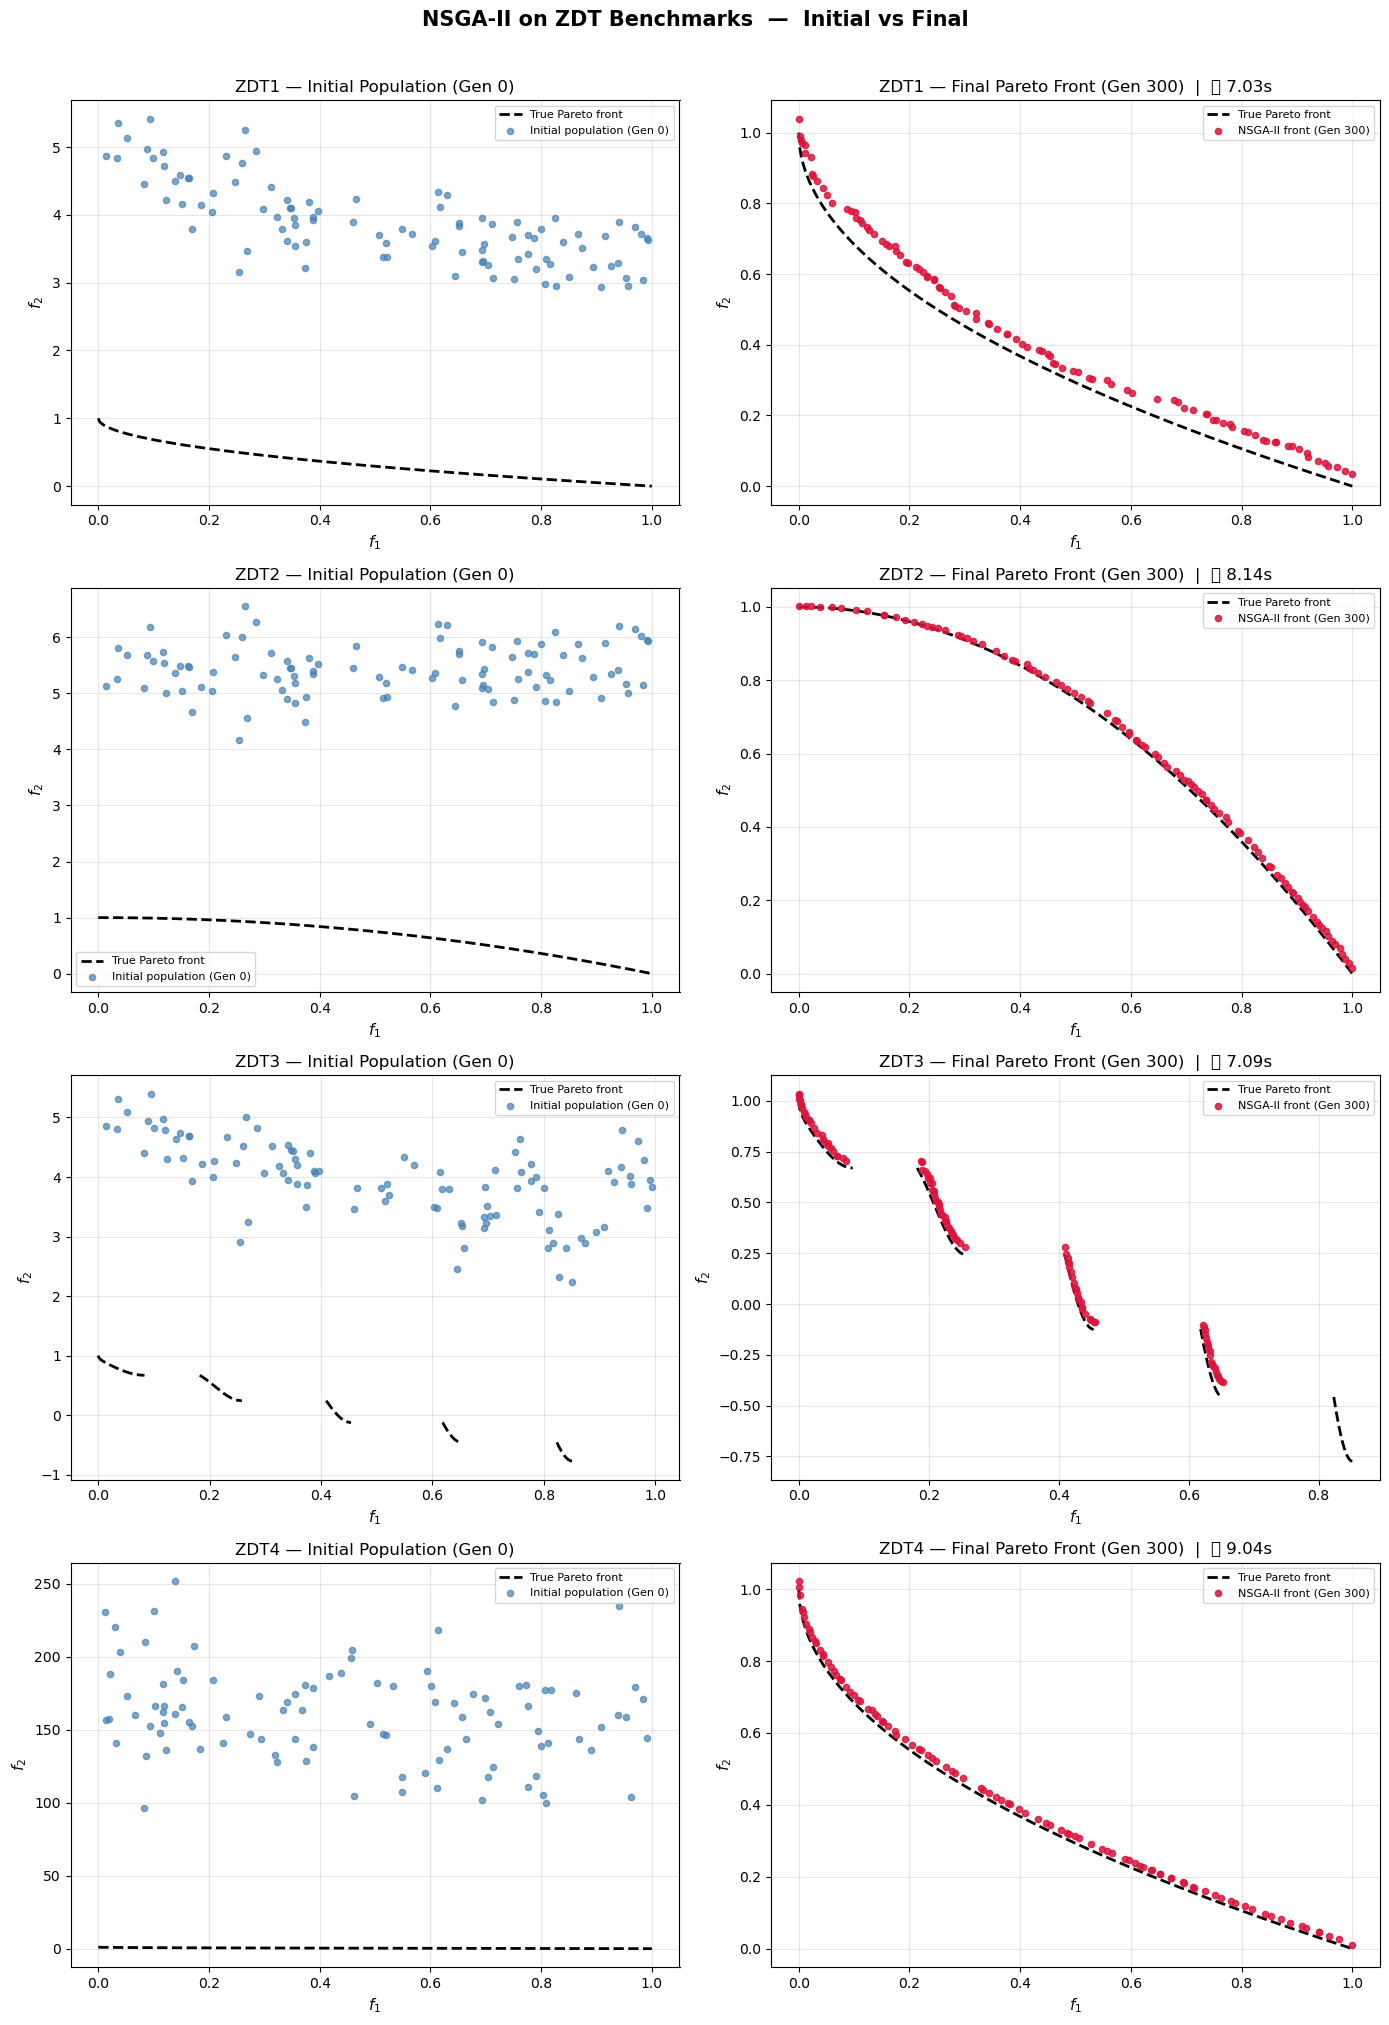

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# ZDT Problem Definitions
# -----------------------------------------------------------------------

def zdt1(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


def zdt2(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - (f1 / g) ** 2)])


def zdt3(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    return np.array([f1, g * h])


def zdt4(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 10 * (n - 1) + np.sum(x[1:] ** 2 - 10 * np.cos(4 * np.pi * x[1:]))
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


# -----------------------------------------------------------------------
# NSGA-II Core Functions
# -----------------------------------------------------------------------

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def non_dominated_sorting(pop_objs):
    """
    IMPROVEMENT: Uses NumPy broadcasting to compute the full dominance
    matrix in one vectorised call instead of a pure-Python double loop,
    cutting runtime of this O(N²) step significantly.
    """
    N = len(pop_objs)

    # --- Vectorised dominance matrix -----------------------------------
    # a_mat[i,j] = True  iff  pop_objs[i] dominates pop_objs[j]
    objs_i = pop_objs[:, np.newaxis, :]   # (N, 1, M)
    objs_j = pop_objs[np.newaxis, :, :]   # (1, N, M)

    all_leq  = np.all(objs_i <= objs_j, axis=2)   # (N, N) — i ≤ j on every obj
    any_less = np.any(objs_i <  objs_j, axis=2)   # (N, N) — i <  j on at least one
    dom_mat  = all_leq & any_less                  # dom_mat[i,j] = i dominates j
    np.fill_diagonal(dom_mat, False)

    n_dom  = dom_mat.sum(axis=0).astype(int)       # how many solutions dominate i
    dom_set = [list(np.where(dom_mat[i])[0]) for i in range(N)]
    # -------------------------------------------------------------------

    fronts = []
    current_front = list(np.where(n_dom == 0)[0])
    fronts.append(current_front)

    while fronts[-1]:
        next_front = []
        for i in fronts[-1]:
            for j in dom_set[i]:
                n_dom[j] -= 1
                if n_dom[j] == 0:
                    next_front.append(j)
        fronts.append(next_front)

    if fronts and fronts[-1] == []:
        fronts.pop()

    return fronts


def crowding_distance(objs, indices):
    n = len(indices)
    if n <= 2:
        return [np.inf] * n

    dist = np.zeros(n)
    idx_to_pos = {idx: pos for pos, idx in enumerate(indices)}

    for m in range(objs.shape[1]):
        sorted_idx = sorted(indices, key=lambda i: objs[i, m])
        dist[idx_to_pos[sorted_idx[0]]]  = np.inf
        dist[idx_to_pos[sorted_idx[-1]]] = np.inf

        f_min = objs[sorted_idx[0],  m]
        f_max = objs[sorted_idx[-1], m]

        if f_max - f_min > 0:
            for k in range(1, n - 1):
                dist[idx_to_pos[sorted_idx[k]]] += (
                    objs[sorted_idx[k + 1], m] - objs[sorted_idx[k - 1], m]
                ) / (f_max - f_min)

    return list(dist)


def tournament_selection(ranks, crowding):
    """
    IMPROVEMENT: Sample i and j WITHOUT replacement so a solution is
    never compared against itself, removing the self-tournament bias.
    """
    i, j = np.random.choice(len(ranks), size=2, replace=False)

    if ranks[i] < ranks[j]:
        return i
    elif ranks[j] < ranks[i]:
        return j
    elif crowding[i] > crowding[j]:
        return i
    else:
        return j


def sbx_crossover(p1, p2, eta_c, xl, xu):
    u = np.random.random(len(p1))
    beta = np.where(
        u <= 0.5,
        (2.0 * u) ** (1.0 / (eta_c + 1)),
        (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1))
    )
    y1 = 0.5 * ((1 + beta) * p1 + (1 - beta) * p2)
    y2 = 0.5 * ((1 - beta) * p1 + (1 + beta) * p2)
    return np.clip(y1, xl, xu), np.clip(y2, xl, xu)


def polynomial_mutation(ind, eta_m, pm, xl, xu):
    """
    IMPROVEMENT: Fully vectorised — replaces the pure-Python per-variable
    for-loop with NumPy operations, giving a significant speedup for large
    n_var (e.g. 30 variables).
    """
    y      = ind.copy()
    mask   = np.random.random(len(ind)) < pm          # which genes mutate

    if not np.any(mask):
        return y

    r      = np.random.random(len(ind))
    delta  = np.where(
        r < 0.5,
        (2.0 * r) ** (1.0 / (eta_m + 1)) - 1.0,
        1.0 - (2.0 * (1.0 - r)) ** (1.0 / (eta_m + 1))
    )
    y[mask] += delta[mask] * (xu[mask] - xl[mask])
    return np.clip(y, xl, xu)


# -----------------------------------------------------------------------
# IMPROVEMENT: compute_ranks_and_crowding moved to module level
# (was re-defined inside nsga2() on every call — wasteful)
# -----------------------------------------------------------------------

def compute_ranks_and_crowding(objs, size):
    fronts   = non_dominated_sorting(objs)
    ranks    = np.zeros(size, dtype=int)
    crowding = np.zeros(size)
    for rk, front in enumerate(fronts):
        for i in front:
            ranks[i] = rk
        cd = crowding_distance(objs, front)
        for pos, i in enumerate(front):
            crowding[i] = cd[pos]
    return ranks, crowding, fronts


# -----------------------------------------------------------------------
# Main NSGA-II Loop
# -----------------------------------------------------------------------

def nsga2(problem_func, n_var, bounds,
          pop_size=100, n_gen=200,
          pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42):
    """
    Returns
    -------
    population   : ndarray  Final population (decision variables)
    objectives   : ndarray  Final objective values
    init_objs    : ndarray  Objective values of the initial random population
    phase_times  : dict     Cumulative wall-clock seconds per internal phase:
                              'init'       — population init + first eval
                              'selection'  — tournament selection
                              'variation'  — SBX crossover + poly mutation
                              'evaluation' — offspring objective evaluation
                              'survival'   — merge + NDS + survivor selection
    """
    np.random.seed(seed)

    xl = np.array([b[0] for b in bounds])
    xu = np.array([b[1] for b in bounds])

    if pm is None:
        pm = 1.0 / n_var

    phase_times = dict(init=0.0, selection=0.0,
                       variation=0.0, evaluation=0.0, survival=0.0)

    # ------------------------------------------------------------------
    # Phase: Initialization
    # ------------------------------------------------------------------
    t0 = time.perf_counter()
    population = np.array([np.random.uniform(xl, xu) for _ in range(pop_size)])
    objectives = np.array([problem_func(ind) for ind in population])
    init_objectives = objectives.copy()
    ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
    phase_times['init'] += time.perf_counter() - t0

    # ------------------------------------------------------------------
    # Generational loop
    # ------------------------------------------------------------------
    for gen in range(n_gen):

        # ---- Phase: Selection ----------------------------------------
        t0 = time.perf_counter()
        mating_pool = np.array([
            population[tournament_selection(ranks, crowding)]
            for _ in range(pop_size)
        ])
        phase_times['selection'] += time.perf_counter() - t0

        # ---- Phase: Variation ----------------------------------------
        # IMPROVEMENT: offspring_raw dead variable removed
        t0 = time.perf_counter()
        offspring_pop = []
        for k in range(0, pop_size, 2):
            p1 = mating_pool[k]
            p2 = mating_pool[k + 1] if k + 1 < pop_size else mating_pool[0]

            if np.random.random() < pc:
                c1, c2 = sbx_crossover(p1, p2, eta_c, xl, xu)
            else:
                c1, c2 = p1.copy(), p2.copy()

            offspring_pop.append(polynomial_mutation(c1, eta_m, pm, xl, xu))
            offspring_pop.append(polynomial_mutation(c2, eta_m, pm, xl, xu))

        offspring_pop = np.array(offspring_pop[:pop_size])
        phase_times['variation'] += time.perf_counter() - t0

        # ---- Phase: Evaluation ---------------------------------------
        t0 = time.perf_counter()
        offspring_objs = np.array([problem_func(ind) for ind in offspring_pop])
        phase_times['evaluation'] += time.perf_counter() - t0

        # ---- Phase: Survival selection -------------------------------
        t0 = time.perf_counter()
        combined_pop  = np.vstack((population, offspring_pop))
        combined_objs = np.vstack((objectives, offspring_objs))

        ranks_comb, crowding_comb, _ = compute_ranks_and_crowding(
            combined_objs, len(combined_pop)
        )

        # IMPROVEMENT: np.lexsort replaces Python sorted() + lambda
        # np.lexsort sorts by last key first, so: primary = rank (asc),
        # secondary = crowding (desc, hence negative)
        sorted_indices = np.lexsort((-crowding_comb, ranks_comb))
        survivors  = sorted_indices[:pop_size]
        population = combined_pop[survivors]
        objectives = combined_objs[survivors]

        ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
        phase_times['survival'] += time.perf_counter() - t0

        if (gen + 1) % 50 == 0:
            n_front0 = len(fronts[0]) if fronts else 0
            print(f"  Gen {gen + 1:4d}/{n_gen} | Front-0 size: {n_front0}")

    return population, objectives, init_objectives, phase_times


# -----------------------------------------------------------------------
# True Pareto Fronts
# -----------------------------------------------------------------------

def true_pareto_zdt1():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - np.sqrt(f1)


def true_pareto_zdt2():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - f1 ** 2


def true_pareto_zdt3():
    intervals = [
        (0.0000, 0.0830), (0.1822, 0.2577), (0.4093, 0.4538),
        (0.6183, 0.6525), (0.8233, 0.8518)
    ]
    f1_list, f2_list = [], []
    for a, b in intervals:
        f1 = np.linspace(a, b, 200)
        f2 = 1 - np.sqrt(f1) - f1 * np.sin(10 * np.pi * f1)
        f1_list.extend(list(f1) + [np.nan])
        f2_list.extend(list(f2) + [np.nan])
    return np.array(f1_list[:-1]), np.array(f2_list[:-1])


def true_pareto_zdt4():
    return true_pareto_zdt1()


# -----------------------------------------------------------------------
# Timing summary
# -----------------------------------------------------------------------

def print_timing_summary(name, total_time, phase_times, n_gen):
    phases_total = sum(phase_times.values())
    overhead     = total_time - phases_total       # time outside timed blocks
    print(f"\n  ┌─ Timing Summary: {name} {'─'*30}")
    print(f"  │  Total wall-clock time  : {total_time:8.3f} s")
    print(f"  │  Generations            : {n_gen}")
    print(f"  │  Avg time / generation  : {total_time / n_gen * 1000:8.2f} ms")
    print(f"  │")
    print(f"  │  Phase breakdown (cumulative across all generations):")
    for phase, t in phase_times.items():
        pct = 100.0 * t / total_time
        bar = '█' * int(pct / 2)
        print(f"  │    {phase:<12s}: {t:7.3f} s  ({pct:5.1f}%)  {bar}")
    # IMPROVEMENT: overhead line added so percentages always sum to 100 %
    overhead_pct = 100.0 * overhead / total_time
    print(f"  │    {'overhead':<12s}: {overhead:7.3f} s  ({overhead_pct:5.1f}%)")
    print(f"  └{'─'*50}")


# -----------------------------------------------------------------------
# Plotting helper
# -----------------------------------------------------------------------

def plot_problem(ax_init, ax_final, name,
                 init_objs, final_objs,
                 f1_true, f2_true, n_gen, total_time):

    ax_init.plot(f1_true, f2_true, 'k--', linewidth=2,
                 label='True Pareto front', zorder=2)
    ax_init.scatter(init_objs[:, 0], init_objs[:, 1],
                    c='steelblue', s=20, alpha=0.7,
                    label='Initial population (Gen 0)', zorder=3)
    ax_init.set_xlabel('$f_1$', fontsize=11)
    ax_init.set_ylabel('$f_2$', fontsize=11)
    ax_init.set_title(f'{name} — Initial Population (Gen 0)', fontsize=12)
    ax_init.legend(fontsize=8)
    ax_init.grid(True, alpha=0.3)

    ax_final.plot(f1_true, f2_true, 'k--', linewidth=2,
                  label='True Pareto front', zorder=2)
    ax_final.scatter(final_objs[:, 0], final_objs[:, 1],
                     c='crimson', s=20, alpha=0.85,
                     label=f'NSGA-II front (Gen {n_gen})', zorder=3)
    ax_final.set_xlabel('$f_1$', fontsize=11)
    ax_final.set_ylabel('$f_2$', fontsize=11)
    ax_final.set_title(
        f'{name} — Final Pareto Front (Gen {n_gen})  |  ⏱ {total_time:.2f}s',
        fontsize=12
    )
    ax_final.legend(fontsize=8)
    ax_final.grid(True, alpha=0.3)


# -----------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------

def main():
    problems = [
        ("ZDT1", zdt1, 30, [(0, 1)] * 30,             true_pareto_zdt1, 300),
        ("ZDT2", zdt2, 30, [(0, 1)] * 30,             true_pareto_zdt2, 300),
        ("ZDT3", zdt3, 30, [(0, 1)] * 30,             true_pareto_zdt3, 300),
        ("ZDT4", zdt4, 10, [(0, 1)] + [(-5, 5)] * 9,  true_pareto_zdt4, 300),
    ]

    n_problems = len(problems)
    fig, axes  = plt.subplots(n_problems, 2, figsize=(14, 5 * n_problems))

    timing_records = []
    overall_start  = time.perf_counter()

    for row, (name, func, n_var, bounds, true_func, n_gen) in enumerate(problems):
        print(f"\n{'='*60}")
        print(f"  Solving {name} | pop=100 | gen={n_gen} | "
              f"pc=0.9 | pm=1/n | eta_c=15 | eta_m=20")
        print(f"{'='*60}")

        problem_start = time.perf_counter()
        pop, objs, init_objs, phase_times = nsga2(
            func, n_var, bounds,
            pop_size=100, n_gen=n_gen,
            pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42
        )
        total_time = time.perf_counter() - problem_start

        fronts = non_dominated_sorting(objs)
        front0 = objs[fronts[0]]
        front0 = front0[np.argsort(front0[:, 0])]

        f1_true, f2_true = true_func()
        plot_problem(axes[row, 0], axes[row, 1], name,
                     init_objs, front0,
                     f1_true, f2_true, n_gen, total_time)

        print_timing_summary(name, total_time, phase_times, n_gen)
        timing_records.append(
            dict(name=name, n_gen=n_gen, total=total_time, phases=phase_times)
        )
        print(f"\n  ✓ {name} done | Initial pop: {len(init_objs)} | "
              f"Final front-0: {len(front0)} | Time: {total_time:.3f}s")

    overall_time = time.perf_counter() - overall_start

    # Consolidated table
    print(f"\n{'='*60}")
    print(f"  CONSOLIDATED TIMING TABLE")
    print(f"{'='*60}")
    header = (f"  {'Problem':<8} {'Gens':>5} {'Total(s)':>10} {'Init(s)':>9} "
              f"{'Select(s)':>10} {'Vary(s)':>9} {'Eval(s)':>9} "
              f"{'Survive(s)':>11} {'ms/gen':>8}")
    print(header)
    print(f"  {'-'*98}")
    for r in timing_records:
        p  = r['phases']
        ms = r['total'] / r['n_gen'] * 1000
        print(
            f"  {r['name']:<8} {r['n_gen']:>5} {r['total']:>10.3f} "
            f"{p['init']:>9.3f} {p['selection']:>10.3f} {p['variation']:>9.3f} "
            f"{p['evaluation']:>9.3f} {p['survival']:>11.3f} {ms:>8.2f}"
        )
    print(f"  {'-'*98}")
    print(f"  {'TOTAL':<8} {'':>5} {overall_time:>10.3f}")
    print(f"{'='*60}")

    plt.suptitle('NSGA-II on ZDT Benchmarks  —  Initial vs Final',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as ZDT_initial_vs_final_improved.png")
    plt.show()


if __name__ == "__main__":
    main()


  Solving ZDT1 | pop=100 | gen=400 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/400 | Front-0 size: 97
  Gen  100/400 | Front-0 size: 89
  Gen  150/400 | Front-0 size: 100
  Gen  200/400 | Front-0 size: 100
  Gen  250/400 | Front-0 size: 100
  Gen  300/400 | Front-0 size: 100
  Gen  350/400 | Front-0 size: 100
  Gen  400/400 | Front-0 size: 100

  ┌─ Timing Summary: ZDT1 ──────────────────────────────
  │  Total wall-clock time  :    6.924 s
  │  Generations            : 400
  │  Avg time / generation  :    17.31 ms
  │
  │  Phase breakdown (cumulative across all generations):
  │    init        :   0.006 s  (  0.1%)  
  │    selection   :   0.930 s  ( 13.4%)  ██████
  │    variation   :   2.955 s  ( 42.7%)  █████████████████████
  │    evaluation  :   0.432 s  (  6.2%)  ███
  │    survival    :   2.598 s  ( 37.5%)  ██████████████████
  │    overhead    :   0.003 s  (  0.0%)
  └──────────────────────────────────────────────────

  ✓ ZDT1 done | Initial pop: 100 | Final front-0: 

C:\Users\hp\AppData\Local\Temp\ipykernel_12032\1062457596.py:448: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_12032\1062457596.py:449: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')



Plot saved as ZDT_initial_vs_final_improved.png


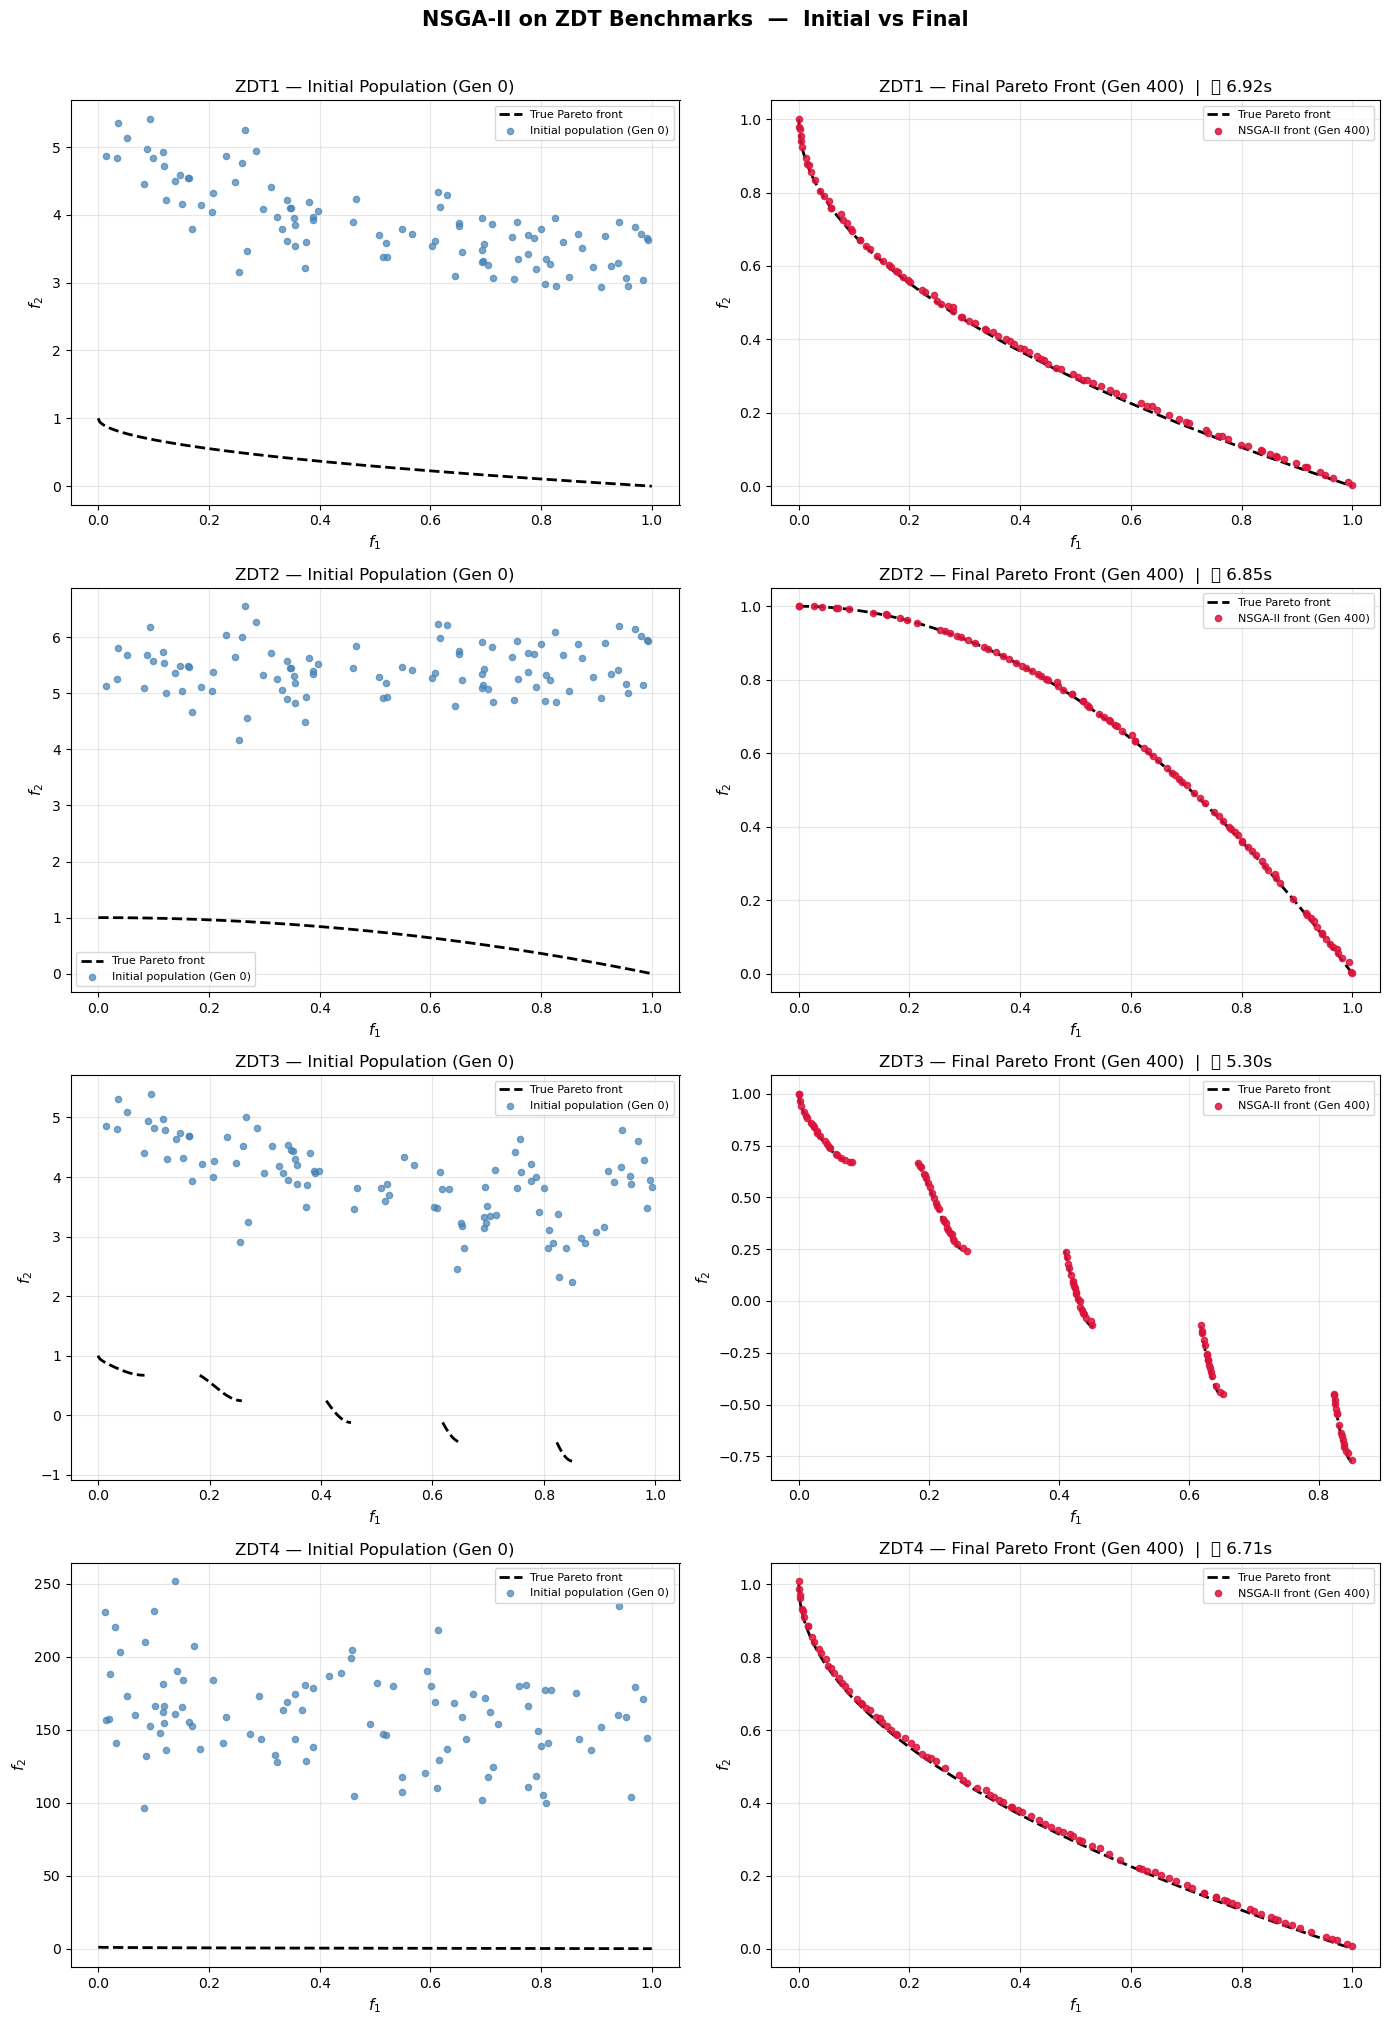

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# ZDT Problem Definitions
# -----------------------------------------------------------------------

def zdt1(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


def zdt2(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    return np.array([f1, g * (1 - (f1 / g) ** 2)])


def zdt3(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    return np.array([f1, g * h])


def zdt4(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 10 * (n - 1) + np.sum(x[1:] ** 2 - 10 * np.cos(4 * np.pi * x[1:]))
    return np.array([f1, g * (1 - np.sqrt(f1 / g))])


# -----------------------------------------------------------------------
# NSGA-II Core Functions
# -----------------------------------------------------------------------

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def non_dominated_sorting(pop_objs):
    """
    IMPROVEMENT: Uses NumPy broadcasting to compute the full dominance
    matrix in one vectorised call instead of a pure-Python double loop,
    cutting runtime of this O(N²) step significantly.
    """
    N = len(pop_objs)

    # --- Vectorised dominance matrix -----------------------------------
    # a_mat[i,j] = True  iff  pop_objs[i] dominates pop_objs[j]
    objs_i = pop_objs[:, np.newaxis, :]   # (N, 1, M)
    objs_j = pop_objs[np.newaxis, :, :]   # (1, N, M)

    all_leq  = np.all(objs_i <= objs_j, axis=2)   # (N, N) — i ≤ j on every obj
    any_less = np.any(objs_i <  objs_j, axis=2)   # (N, N) — i <  j on at least one
    dom_mat  = all_leq & any_less                  # dom_mat[i,j] = i dominates j
    np.fill_diagonal(dom_mat, False)

    n_dom  = dom_mat.sum(axis=0).astype(int)       # how many solutions dominate i
    dom_set = [list(np.where(dom_mat[i])[0]) for i in range(N)]
    # -------------------------------------------------------------------

    fronts = []
    current_front = list(np.where(n_dom == 0)[0])
    fronts.append(current_front)

    while fronts[-1]:
        next_front = []
        for i in fronts[-1]:
            for j in dom_set[i]:
                n_dom[j] -= 1
                if n_dom[j] == 0:
                    next_front.append(j)
        fronts.append(next_front)

    if fronts and fronts[-1] == []:
        fronts.pop()

    return fronts


def crowding_distance(objs, indices):
    n = len(indices)
    if n <= 2:
        return [np.inf] * n

    dist = np.zeros(n)
    idx_to_pos = {idx: pos for pos, idx in enumerate(indices)}

    for m in range(objs.shape[1]):
        sorted_idx = sorted(indices, key=lambda i: objs[i, m])
        dist[idx_to_pos[sorted_idx[0]]]  = np.inf
        dist[idx_to_pos[sorted_idx[-1]]] = np.inf

        f_min = objs[sorted_idx[0],  m]
        f_max = objs[sorted_idx[-1], m]

        if f_max - f_min > 0:
            for k in range(1, n - 1):
                dist[idx_to_pos[sorted_idx[k]]] += (
                    objs[sorted_idx[k + 1], m] - objs[sorted_idx[k - 1], m]
                ) / (f_max - f_min)

    return list(dist)


def tournament_selection(ranks, crowding):
    """
    IMPROVEMENT: Sample i and j WITHOUT replacement so a solution is
    never compared against itself, removing the self-tournament bias.
    """
    i, j = np.random.choice(len(ranks), size=2, replace=False)

    if ranks[i] < ranks[j]:
        return i
    elif ranks[j] < ranks[i]:
        return j
    elif crowding[i] > crowding[j]:
        return i
    else:
        return j


def sbx_crossover(p1, p2, eta_c, xl, xu):
    u = np.random.random(len(p1))
    beta = np.where(
        u <= 0.5,
        (2.0 * u) ** (1.0 / (eta_c + 1)),
        (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1))
    )
    y1 = 0.5 * ((1 + beta) * p1 + (1 - beta) * p2)
    y2 = 0.5 * ((1 - beta) * p1 + (1 + beta) * p2)
    return np.clip(y1, xl, xu), np.clip(y2, xl, xu)


def polynomial_mutation(ind, eta_m, pm, xl, xu):
    """
    IMPROVEMENT: Fully vectorised — replaces the pure-Python per-variable
    for-loop with NumPy operations, giving a significant speedup for large
    n_var (e.g. 30 variables).
    """
    y      = ind.copy()
    mask   = np.random.random(len(ind)) < pm          # which genes mutate

    if not np.any(mask):
        return y

    r      = np.random.random(len(ind))
    delta  = np.where(
        r < 0.5,
        (2.0 * r) ** (1.0 / (eta_m + 1)) - 1.0,
        1.0 - (2.0 * (1.0 - r)) ** (1.0 / (eta_m + 1))
    )
    y[mask] += delta[mask] * (xu[mask] - xl[mask])
    return np.clip(y, xl, xu)


# -----------------------------------------------------------------------
# IMPROVEMENT: compute_ranks_and_crowding moved to module level
# (was re-defined inside nsga2() on every call — wasteful)
# -----------------------------------------------------------------------

def compute_ranks_and_crowding(objs, size):
    fronts   = non_dominated_sorting(objs)
    ranks    = np.zeros(size, dtype=int)
    crowding = np.zeros(size)
    for rk, front in enumerate(fronts):
        for i in front:
            ranks[i] = rk
        cd = crowding_distance(objs, front)
        for pos, i in enumerate(front):
            crowding[i] = cd[pos]
    return ranks, crowding, fronts


# -----------------------------------------------------------------------
# Main NSGA-II Loop
# -----------------------------------------------------------------------

def nsga2(problem_func, n_var, bounds,
          pop_size=100, n_gen=200,
          pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42):
    """
    Returns
    -------
    population   : ndarray  Final population (decision variables)
    objectives   : ndarray  Final objective values
    init_objs    : ndarray  Objective values of the initial random population
    phase_times  : dict     Cumulative wall-clock seconds per internal phase:
                              'init'       — population init + first eval
                              'selection'  — tournament selection
                              'variation'  — SBX crossover + poly mutation
                              'evaluation' — offspring objective evaluation
                              'survival'   — merge + NDS + survivor selection
    """
    np.random.seed(seed)

    xl = np.array([b[0] for b in bounds])
    xu = np.array([b[1] for b in bounds])

    if pm is None:
        pm = 1.0 / n_var

    phase_times = dict(init=0.0, selection=0.0,
                       variation=0.0, evaluation=0.0, survival=0.0)

    # ------------------------------------------------------------------
    # Phase: Initialization
    # ------------------------------------------------------------------
    t0 = time.perf_counter()
    population = np.array([np.random.uniform(xl, xu) for _ in range(pop_size)])
    objectives = np.array([problem_func(ind) for ind in population])
    init_objectives = objectives.copy()
    ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
    phase_times['init'] += time.perf_counter() - t0

    # ------------------------------------------------------------------
    # Generational loop
    # ------------------------------------------------------------------
    for gen in range(n_gen):

        # ---- Phase: Selection ----------------------------------------
        t0 = time.perf_counter()
        mating_pool = np.array([
            population[tournament_selection(ranks, crowding)]
            for _ in range(pop_size)
        ])
        phase_times['selection'] += time.perf_counter() - t0

        # ---- Phase: Variation ----------------------------------------
        # IMPROVEMENT: offspring_raw dead variable removed
        t0 = time.perf_counter()
        offspring_pop = []
        for k in range(0, pop_size, 2):
            p1 = mating_pool[k]
            p2 = mating_pool[k + 1] if k + 1 < pop_size else mating_pool[0]

            if np.random.random() < pc:
                c1, c2 = sbx_crossover(p1, p2, eta_c, xl, xu)
            else:
                c1, c2 = p1.copy(), p2.copy()

            offspring_pop.append(polynomial_mutation(c1, eta_m, pm, xl, xu))
            offspring_pop.append(polynomial_mutation(c2, eta_m, pm, xl, xu))

        offspring_pop = np.array(offspring_pop[:pop_size])
        phase_times['variation'] += time.perf_counter() - t0

        # ---- Phase: Evaluation ---------------------------------------
        t0 = time.perf_counter()
        offspring_objs = np.array([problem_func(ind) for ind in offspring_pop])
        phase_times['evaluation'] += time.perf_counter() - t0

        # ---- Phase: Survival selection -------------------------------
        t0 = time.perf_counter()
        combined_pop  = np.vstack((population, offspring_pop))
        combined_objs = np.vstack((objectives, offspring_objs))

        ranks_comb, crowding_comb, _ = compute_ranks_and_crowding(
            combined_objs, len(combined_pop)
        )

        # IMPROVEMENT: np.lexsort replaces Python sorted() + lambda
        # np.lexsort sorts by last key first, so: primary = rank (asc),
        # secondary = crowding (desc, hence negative)
        sorted_indices = np.lexsort((-crowding_comb, ranks_comb))
        survivors  = sorted_indices[:pop_size]
        population = combined_pop[survivors]
        objectives = combined_objs[survivors]

        ranks, crowding, fronts = compute_ranks_and_crowding(objectives, pop_size)
        phase_times['survival'] += time.perf_counter() - t0

        if (gen + 1) % 50 == 0:
            n_front0 = len(fronts[0]) if fronts else 0
            print(f"  Gen {gen + 1:4d}/{n_gen} | Front-0 size: {n_front0}")

    return population, objectives, init_objectives, phase_times


# -----------------------------------------------------------------------
# True Pareto Fronts
# -----------------------------------------------------------------------

def true_pareto_zdt1():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - np.sqrt(f1)


def true_pareto_zdt2():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - f1 ** 2


def true_pareto_zdt3():
    intervals = [
        (0.0000, 0.0830), (0.1822, 0.2577), (0.4093, 0.4538),
        (0.6183, 0.6525), (0.8233, 0.8518)
    ]
    f1_list, f2_list = [], []
    for a, b in intervals:
        f1 = np.linspace(a, b, 200)
        f2 = 1 - np.sqrt(f1) - f1 * np.sin(10 * np.pi * f1)
        f1_list.extend(list(f1) + [np.nan])
        f2_list.extend(list(f2) + [np.nan])
    return np.array(f1_list[:-1]), np.array(f2_list[:-1])


def true_pareto_zdt4():
    return true_pareto_zdt1()


# -----------------------------------------------------------------------
# Timing summary
# -----------------------------------------------------------------------

def print_timing_summary(name, total_time, phase_times, n_gen):
    phases_total = sum(phase_times.values())
    overhead     = total_time - phases_total       # time outside timed blocks
    print(f"\n  ┌─ Timing Summary: {name} {'─'*30}")
    print(f"  │  Total wall-clock time  : {total_time:8.3f} s")
    print(f"  │  Generations            : {n_gen}")
    print(f"  │  Avg time / generation  : {total_time / n_gen * 1000:8.2f} ms")
    print(f"  │")
    print(f"  │  Phase breakdown (cumulative across all generations):")
    for phase, t in phase_times.items():
        pct = 100.0 * t / total_time
        bar = '█' * int(pct / 2)
        print(f"  │    {phase:<12s}: {t:7.3f} s  ({pct:5.1f}%)  {bar}")
    # IMPROVEMENT: overhead line added so percentages always sum to 100 %
    overhead_pct = 100.0 * overhead / total_time
    print(f"  │    {'overhead':<12s}: {overhead:7.3f} s  ({overhead_pct:5.1f}%)")
    print(f"  └{'─'*50}")


# -----------------------------------------------------------------------
# Plotting helper
# -----------------------------------------------------------------------

def plot_problem(ax_init, ax_final, name,
                 init_objs, final_objs,
                 f1_true, f2_true, n_gen, total_time):

    ax_init.plot(f1_true, f2_true, 'k--', linewidth=2,
                 label='True Pareto front', zorder=2)
    ax_init.scatter(init_objs[:, 0], init_objs[:, 1],
                    c='steelblue', s=20, alpha=0.7,
                    label='Initial population (Gen 0)', zorder=3)
    ax_init.set_xlabel('$f_1$', fontsize=11)
    ax_init.set_ylabel('$f_2$', fontsize=11)
    ax_init.set_title(f'{name} — Initial Population (Gen 0)', fontsize=12)
    ax_init.legend(fontsize=8)
    ax_init.grid(True, alpha=0.3)

    ax_final.plot(f1_true, f2_true, 'k--', linewidth=2,
                  label='True Pareto front', zorder=2)
    ax_final.scatter(final_objs[:, 0], final_objs[:, 1],
                     c='crimson', s=20, alpha=0.85,
                     label=f'NSGA-II front (Gen {n_gen})', zorder=3)
    ax_final.set_xlabel('$f_1$', fontsize=11)
    ax_final.set_ylabel('$f_2$', fontsize=11)
    ax_final.set_title(
        f'{name} — Final Pareto Front (Gen {n_gen})  |  ⏱ {total_time:.2f}s',
        fontsize=12
    )
    ax_final.legend(fontsize=8)
    ax_final.grid(True, alpha=0.3)


# -----------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------

def main():
    problems = [
        ("ZDT1", zdt1, 30, [(0, 1)] * 30,             true_pareto_zdt1, 400),
        ("ZDT2", zdt2, 30, [(0, 1)] * 30,             true_pareto_zdt2, 400),
        ("ZDT3", zdt3, 30, [(0, 1)] * 30,             true_pareto_zdt3, 400),
        ("ZDT4", zdt4, 10, [(0, 1)] + [(-5, 5)] * 9,  true_pareto_zdt4, 400),
    ]

    n_problems = len(problems)
    fig, axes  = plt.subplots(n_problems, 2, figsize=(14, 5 * n_problems))

    timing_records = []
    overall_start  = time.perf_counter()

    for row, (name, func, n_var, bounds, true_func, n_gen) in enumerate(problems):
        print(f"\n{'='*60}")
        print(f"  Solving {name} | pop=100 | gen={n_gen} | "
              f"pc=0.9 | pm=1/n | eta_c=15 | eta_m=20")
        print(f"{'='*60}")

        problem_start = time.perf_counter()
        pop, objs, init_objs, phase_times = nsga2(
            func, n_var, bounds,
            pop_size=100, n_gen=n_gen,
            pc=0.9, pm=None, eta_c=15, eta_m=20, seed=42
        )
        total_time = time.perf_counter() - problem_start

        fronts = non_dominated_sorting(objs)
        front0 = objs[fronts[0]]
        front0 = front0[np.argsort(front0[:, 0])]

        f1_true, f2_true = true_func()
        plot_problem(axes[row, 0], axes[row, 1], name,
                     init_objs, front0,
                     f1_true, f2_true, n_gen, total_time)

        print_timing_summary(name, total_time, phase_times, n_gen)
        timing_records.append(
            dict(name=name, n_gen=n_gen, total=total_time, phases=phase_times)
        )
        print(f"\n  ✓ {name} done | Initial pop: {len(init_objs)} | "
              f"Final front-0: {len(front0)} | Time: {total_time:.3f}s")

    overall_time = time.perf_counter() - overall_start

    # Consolidated table
    print(f"\n{'='*60}")
    print(f"  CONSOLIDATED TIMING TABLE")
    print(f"{'='*60}")
    header = (f"  {'Problem':<8} {'Gens':>5} {'Total(s)':>10} {'Init(s)':>9} "
              f"{'Select(s)':>10} {'Vary(s)':>9} {'Eval(s)':>9} "
              f"{'Survive(s)':>11} {'ms/gen':>8}")
    print(header)
    print(f"  {'-'*98}")
    for r in timing_records:
        p  = r['phases']
        ms = r['total'] / r['n_gen'] * 1000
        print(
            f"  {r['name']:<8} {r['n_gen']:>5} {r['total']:>10.3f} "
            f"{p['init']:>9.3f} {p['selection']:>10.3f} {p['variation']:>9.3f} "
            f"{p['evaluation']:>9.3f} {p['survival']:>11.3f} {ms:>8.2f}"
        )
    print(f"  {'-'*98}")
    print(f"  {'TOTAL':<8} {'':>5} {overall_time:>10.3f}")
    print(f"{'='*60}")

    plt.suptitle('NSGA-II on ZDT Benchmarks  —  Initial vs Final',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ZDT_initial_vs_final_improved.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as ZDT_initial_vs_final_improved.png")
    plt.show()


if __name__ == "__main__":
    main()